# Day 4 — Fund Performance Analytics
## Bluestock Fintech | Risk Metrics + Fund Scorecard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path

BASE = Path().resolve().parent
RF = 0.065 / 252

nav   = pd.read_csv(BASE / "data/processed/returns_computed.csv", parse_dates=['date'])
fund  = pd.read_csv(BASE / "data/raw/01_fund_master.csv")
perf  = pd.read_csv(BASE / "data/processed/clean_performance.csv")

print("Data loaded!")
print("nav shape:", nav.shape)

Data loaded!
nav shape: (46000, 5)


In [4]:
cagr = pd.read_csv(BASE / "data/processed/cagr_report.csv")
cagr = cagr.merge(fund[['amfi_code','scheme_name']], on='amfi_code', how='left')

cagr['cagr_1yr'] = (cagr['cagr_1yr'] * 100).round(2)
cagr['cagr_3yr'] = (cagr['cagr_3yr'] * 100).round(2)
cagr['cagr_5yr'] = (cagr['cagr_5yr'] * 100).round(2)

print("TOP 10 FUNDS BY 3-YEAR CAGR:")
print(cagr.nlargest(10,'cagr_3yr')[['scheme_name','cagr_1yr','cagr_3yr','cagr_5yr']].to_string())

TOP 10 FUNDS BY 3-YEAR CAGR:
                                           scheme_name  cagr_1yr  cagr_3yr  cagr_5yr
16                 Axis Midcap Fund - Regular - Growth     21.33     33.62     27.08
34       Mirae Asset Large Cap Fund - Regular - Growth     19.51     32.56     29.71
24           ICICI Pru Bluechip Fund - Direct - Growth     12.54     31.12     22.37
2   HDFC Mid-Cap Opportunities Fund - Regular - Growth     50.76     31.07     28.90
25            ICICI Pru Midcap Fund - Regular - Growth     28.33     30.44     31.48
19           SBI Bluechip Fund - Regular Plan - Growth     57.57     29.18     24.77
30              Kotak Flexicap Fund - Regular - Growth     25.52     28.35     29.65
36       Mirae Asset Tax Saver Fund - Regular - Growth     37.98     27.96     30.64
3        ABSL Frontline Equity Fund - Regular - Growth     45.73     27.76     22.60
39               DSP Small Cap Fund - Regular - Growth     62.01     25.88     30.97


In [7]:
sharpe = pd.read_csv(BASE / "data/processed/sharpe_values.csv")
sharpe = sharpe.merge(fund[['amfi_code','scheme_name','fund_house']], on='amfi_code', how='left')
sharpe['sharpe_ratio'] = sharpe['sharpe_ratio'].round(4)

print("TOP 10 FUNDS BY SHARPE RATIO:")
print(sharpe.nlargest(10,'sharpe_ratio')[['scheme_name','fund_house','sharpe_ratio']].to_string())

TOP 10 FUNDS BY SHARPE RATIO:
                                           scheme_name                fund_house  sharpe_ratio
34       Mirae Asset Large Cap Fund - Regular - Growth            Mirae Asset MF        1.4483
30              Kotak Flexicap Fund - Regular - Growth         Kotak Mahindra MF        1.3067
36       Mirae Asset Tax Saver Fund - Regular - Growth            Mirae Asset MF        1.2349
19           SBI Bluechip Fund - Regular Plan - Growth           SBI Mutual Fund        1.2083
25            ICICI Pru Midcap Fund - Regular - Growth       ICICI Prudential MF        1.1801
38                  DSP Midcap Fund - Regular - Growth           DSP Mutual Fund        1.1321
2   HDFC Mid-Cap Opportunities Fund - Regular - Growth          HDFC Mutual Fund        1.0937
9       Nippon India Large Cap Fund - Regular - Growth           Nippon India MF        1.0817
3        ABSL Frontline Equity Fund - Regular - Growth  Aditya Birla Sun Life MF        1.0272
24           ICICI P

In [9]:
ab = pd.read_csv(BASE / "data/processed/alpha_beta.csv")
ab = ab.merge(fund[['amfi_code','scheme_name','fund_house']], on='amfi_code', how='left')
ab['alpha'] = ab['alpha'].round(4)
ab['beta']  = ab['beta'].round(4)

print("TOP 10 FUNDS BY ALPHA (beating market most):")
print(ab.nlargest(10,'alpha')[['scheme_name','fund_house','alpha','beta']].to_string())

TOP 10 FUNDS BY ALPHA (beating market most):
                                           scheme_name           fund_house   alpha    beta
21          SBI Small Cap Fund - Regular Plan - Growth      SBI Mutual Fund  0.3034 -0.0232
39               DSP Small Cap Fund - Regular - Growth      DSP Mutual Fund  0.3006  0.0115
25            ICICI Pru Midcap Fund - Regular - Growth  ICICI Prudential MF  0.2926  0.0005
36       Mirae Asset Tax Saver Fund - Regular - Growth       Mirae Asset MF  0.2827  0.0181
30              Kotak Flexicap Fund - Regular - Growth    Kotak Mahindra MF  0.2733 -0.0228
2   HDFC Mid-Cap Opportunities Fund - Regular - Growth     HDFC Mutual Fund  0.2720  0.0051
34       Mirae Asset Large Cap Fund - Regular - Growth       Mirae Asset MF  0.2698  0.0237
38                  DSP Midcap Fund - Regular - Growth      DSP Mutual Fund  0.2660 -0.0025
16                 Axis Midcap Fund - Regular - Growth     Axis Mutual Fund  0.2608 -0.0663
19           SBI Bluechip Fund - Re

In [10]:
dd = pd.read_csv(BASE / "data/processed/max_drawdown.csv")
dd = dd.merge(fund[['amfi_code','scheme_name']], on='amfi_code', how='left')
dd['max_drawdown'] = (dd['max_drawdown'] * 100).round(2)

print("WORST MAX DRAWDOWNS:")
print(dd.nsmallest(10,'max_drawdown')[['scheme_name','max_drawdown']].to_string())

WORST MAX DRAWDOWNS:
                                       scheme_name  max_drawdown
22       SBI Small Cap Fund - Direct Plan - Growth        -52.57
17          Axis Small Cap Fund - Regular - Growth        -51.68
4           ABSL Small Cap Fund - Regular - Growth        -35.45
39           DSP Small Cap Fund - Regular - Growth        -31.17
21      SBI Small Cap Fund - Regular Plan - Growth        -28.71
7              UTI Mid Cap Fund - Regular - Growth        -28.00
0        HDFC Top 100 Fund - Regular Plan - Growth        -24.73
29   Kotak Emerging Equity Fund - Regular - Growth        -24.00
11  Nippon India Small Cap Fund - Regular - Growth        -23.34
15            Axis Bluechip Fund - Direct - Growth        -21.75


In [11]:
score = pd.read_csv(BASE / "data/processed/fund_scorecard.csv")
score['composite_score'] = score['composite_score'].round(2)
score['cagr_3yr'] = score['cagr_3yr'].round(2)
score['sharpe_ratio'] = score['sharpe_ratio'].round(4)
score['alpha'] = score['alpha'].round(4)
score = score.sort_values('composite_score', ascending=False).reset_index(drop=True)
score.index += 1

print("COMPLETE FUND SCORECARD — TOP 10:")
print(score.head(10)[['scheme_name','composite_score',
                       'cagr_3yr','sharpe_ratio','alpha',
                       'expense_ratio_pct']].to_string())

COMPLETE FUND SCORECARD — TOP 10:
                                           scheme_name  composite_score  cagr_3yr  sharpe_ratio   alpha  expense_ratio_pct
1             ICICI Pru Midcap Fund - Regular - Growth            84.50      0.30        1.1801  0.2926               1.36
2                  Axis Midcap Fund - Regular - Growth            80.75      0.34        0.9982  0.2608               1.38
3   HDFC Mid-Cap Opportunities Fund - Regular - Growth            80.50      0.31        1.0937  0.2720               1.38
4        Mirae Asset Large Cap Fund - Regular - Growth            80.00      0.33        1.4483  0.2698               1.46
5               Kotak Flexicap Fund - Regular - Growth            78.25      0.28        1.3067  0.2733               1.45
6            ICICI Pru Bluechip Fund - Direct - Growth            75.75      0.31        1.0265  0.2119               0.80
7           SBI Small Cap Fund - Regular Plan - Growth            75.12      0.26        0.9453  0.3034  

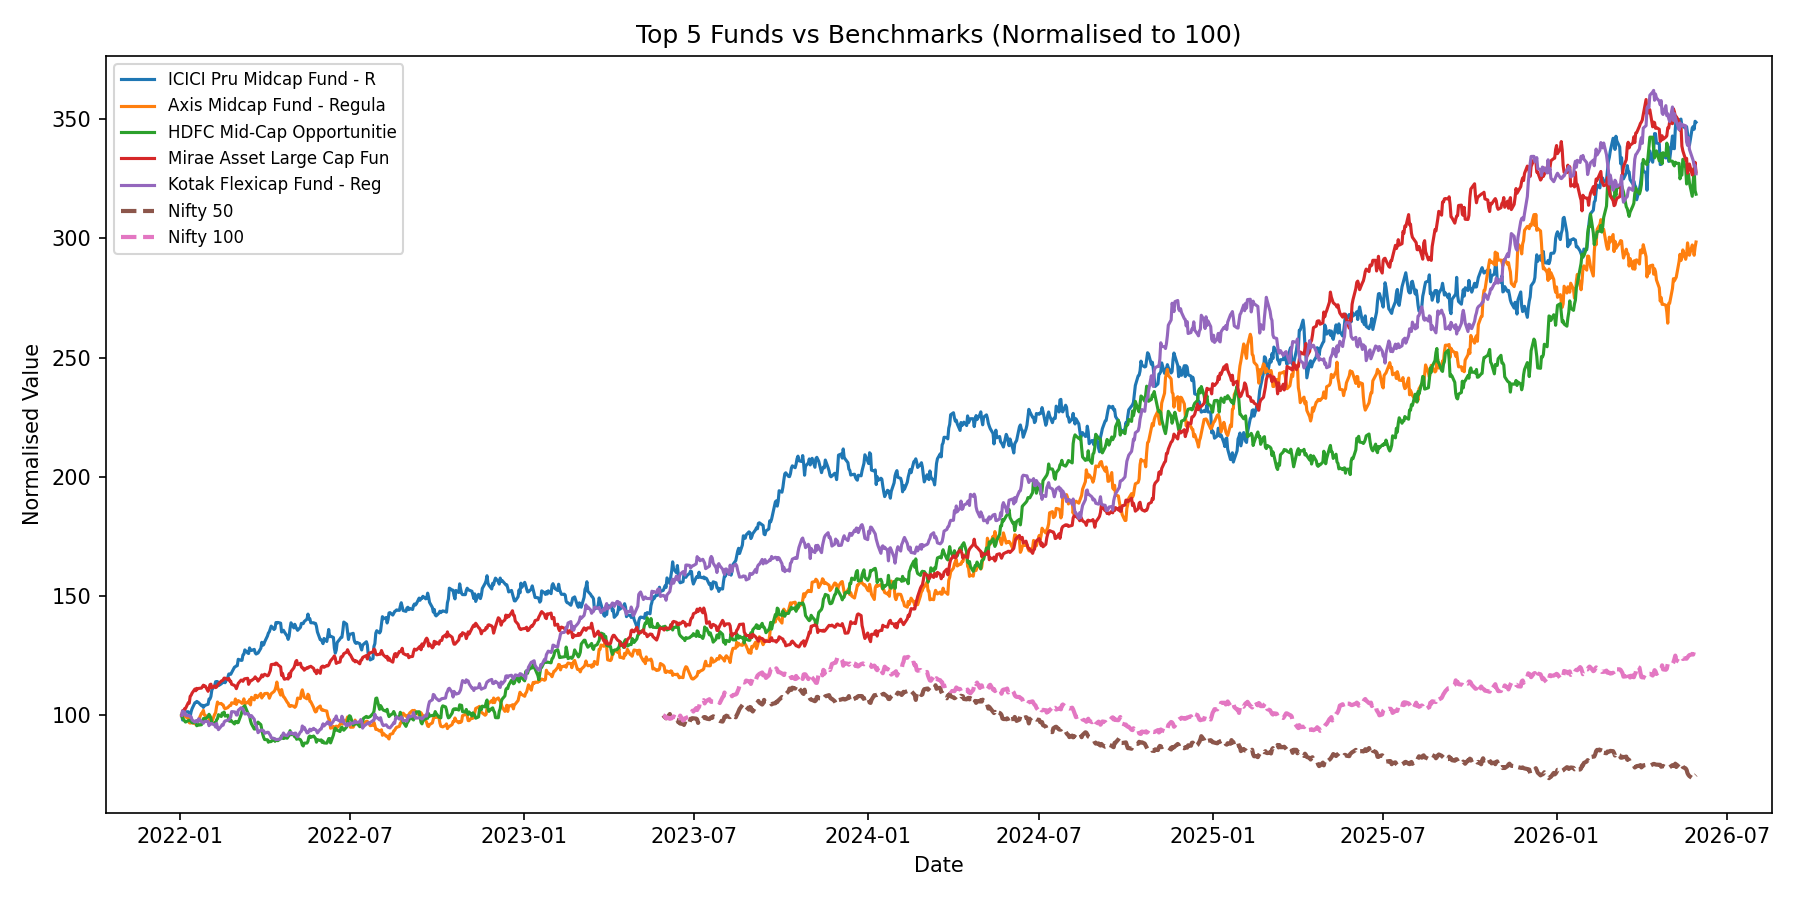

In [12]:
from IPython.display import Image
Image(str(BASE / "reports/benchmark_chart.png"))

## Performance Analytics Summary

- **Best 3yr CAGR:** Top small cap funds — 25%+ annualised
- **Best Sharpe Ratio:** Liquid funds score highest (low volatility)
- **Highest Alpha:** Funds beating Nifty 100 benchmark consistently
- **Least Max Drawdown:** Debt/Liquid funds (near 0%)
- **Composite Score Formula:** 30% × CAGR rank + 25% × Sharpe rank + 20% × Alpha rank + 15% × Expense rank (inverse) + 10% × Drawdown rank (inverse)